In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# NLP and Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Progress bars
from tqdm import tqdm
tqdm.pandas()

# Download required NLTK data
print("Downloading NLTK data...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

# ============================================================================
# LOAD DATA
# ============================================================================
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)
df = pd.read_pickle("../data/categorized/dataset_with_category.pkl")  
print(f"Loaded {len(df)} articles")
print(f"Columns: {df.columns.tolist()}")





LOADING DATA
Loaded 41148 articles
Columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw', 'category']


In [28]:

# ============================================================================
# TEXT PREPROCESSING WITH COMPREHENSIVE STOPWORDS
# ============================================================================
print("\n" + "="*60)
print("PREPROCESSING TEXT")
print("="*60)

def preprocess_text(text):
    """Clean and preprocess text for topic modeling"""
    if pd.isna(text):
        return ""
    
    # Lowercase
    text = str(text).lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = ''.join([char for char in text if not char.isdigit()])
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    custom_stops = {
        # custom stopwords
        'said', 'say', 'mr', 'ms', 'mrs', 'and', 'the', 'are', 'is', 'of', 'in', 'to',
        'that', 'he', 'she', 'was', 'have', 'has', 'had', 'do', 'does', 'did', 'were',
        'been', 'being', 'would', 'could', 'should', 'might', 'will', 'can', 'for',
        'with', 'at', 'by', 'on', 'from', 'as', 'it', 'its', 'this', 'these', 'those',
        'their', 'our', 'your', 'his', 'her', 'him', 'them', 'an', 'a', 'but', 'or',
        'so', 'if', 'because', 'while', 'where', 'when', 'about', 'into', 'over',
        'under', 'people', 'person', 'someone', 'anyone', 'everyone', 'everybody',
        'company', 'organization', 'group', 'government', 'official', 'officials',
        'agency', 'department', 'news', 'report', 'reported', 'according', 'interview',
        'article', 'new', 'year', 'years', 'time', 'day', 'days', 'week', 'weeks',
        'month', 'months',
        
        # Generic/vague words
        'also', 'one', 'two', 'three', 'may', 'like', 'get', 'make', 
        'use', 'used', 'using', 'include', 'including', 'told', 'tell',
        
        # Temporal words
        'last', 'first', 'second', 'next', 
        'today', 'yesterday', 'tomorrow', 'recent', 'recently', 'former', 'current',
        'past', 'future', 'later', 'early', 'late',
        
        # Quantity/degree
        'many', 'much', 'more', 'most', 'less', 'least', 'several', 'few', 
        'number', 'large', 'small', 'big', 'little', 'around', 'near', 'nearly',
        'almost', 'approximately',
        
        # Modifiers/qualifiers
        'really', 'very', 'quite', 'rather', 'pretty', 'fairly', 'somewhat',
        'extremely', 'highly', 'particularly', 'especially', 'generally',
        
        # Discourse markers
        'however', 'therefore', 'moreover', 'furthermore', 'meanwhile', 
        'nevertheless', 'although', 'though', 'since', 'whether', 'either',
        
        # Verbs (common/generic)
        'going', 'come', 'came', 'go', 'goes', 'went', 'gone', 'says',
        'take', 'takes', 'took', 'taken', 'give', 'gives', 'gave', 'given',
        'know', 'knew', 'known', 'think', 'thought', 'want', 'wanted', 'need',
        'become', 'became', 'help', 'helped', 'helping', 'look', 'looking',
        'seem', 'seems', 'seemed', 'find', 'found', 'show', 'shows', 'showed',
        'work', 'works', 'worked', 'working', 'put', 'call', 'called', 'calling',
        'ask', 'asked', 'asking', 'try', 'tried', 'trying', 'start', 'started',
        'begin', 'began', 'begun', 'keep', 'kept', 'keeping', 'turn', 'turned',
        'leave', 'left', 'leaving', 'back', 'bring', 'brought', 'bringing',
        
        # Pronouns/determiners (additional)
        'something', 'anything', 'everything', 'nothing',
        'thing', 'things', 'way', 'ways', 'kind', 'type', 'sort',
        
        # Locations (generic)
        'place', 'area', 'along', 'across', 'among', 'between',
        
        # Common adjectives
        'good', 'bad', 'right', 'wrong', 'different', 'same', 'such', 'own',
        'other', 'another', 'certain', 'sure', 'able', 'available', 'possible',
        'important', 'necessary', 'likely', 'unlikely', 'difficult', 'easy',
        
        # Contractions
        'thats', 'dont', 'doesnt', 'didnt', 'cant', 'couldnt', 'wouldnt',
        'shouldnt', 'isnt', 'arent', 'wasnt', 'werent', 'havent', 'hasnt',
        'hadnt', 'wont', 'ive', 'youve', 'weve', 'theyve', 'im', 'youre',
        'hes', 'shes', 'were', 'theyre',
        
        # News-specific generic words
        'announced', 'announcement', 'reporting', 'reporter',
        'statement', 'spokesperson', 'representative',
        'announced', 'release', 'released',
        
        # Common but not meaningful
        'lot', 'lots', 'bit', 'piece', 'part', 'parts', 'whole', 'half',
        'end', 'side', 'top', 'bottom', 'front', 'left', 'long', 'short', 
        'high', 'low', 'old', 'young',
        
        # Additional vague terms
        'basically', 'actually', 'literally', 'definitely', 'probably',
        'possibly', 'certainly', 'clearly', 'obviously', 'apparently',
        'perhaps', 'maybe', 'must', 'shall', 'ought',
        
        # Common verbs in news
        'continue', 'continued', 'continuing', 'remain', 'remained', 'remaining',
        'included', 'including', 'provide', 'provided', 'providing',
        'offer', 'offered', 'offering', 'support', 'supported', 'supporting',
        
        # Numbers/quantities (written out)
        'zero', 'ten', 'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen',
        'twenty', 'thirty', 'forty', 'fifty', 'hundred', 'thousand', 'million', 'billion',
        
        # Time periods
        'hour', 'hours', 'minute', 'minutes', 'morning', 'afternoon', 'evening',
        'night', 'tonight', 'weekend', 'weekday', 'season', 'spring', 'summer',
        'fall', 'winter', 'century', 'decade', 'era', 'period',
        
        # Additional location terms
        'local', 'regional', 'national', 'international', 'global', 'worldwide',
        'domestic', 'foreign', 'nearby', 'distant', 'close', 'far',
        
        # Relationship words
        'related', 'regarding', 'concerning', 'involving',
        'associated', 'connected', 'linked', 'tied', 'based',
        
        # Additional common words in news
        'example', 'case', 'cases', 'issue', 'issues', 'matter', 'matters',
        'situation', 'situations', 'problem', 'problems', 'question', 'questions',
        'answer', 'answers', 'reason', 'reasons', 'result', 'results',
        'effect', 'effects', 'cause', 'causes', 'change', 'changes',
        'fact', 'facts', 'data', 'information', 'detail', 'details',
        
        # Verbs of being/having
        'becomes', 'becoming', 'remains', 'remaining',
        'stay', 'stays', 'stayed', 'staying', 'gets', 'getting', 'got',
        'gotten', 'having',
        
        # Additional filler words
        'well', 'now', 'just', 'still', 'even', 'yet', 'already', 'soon',
        'enough', 'too', 'never', 'always', 'often',
        'sometimes', 'usually', 'rarely', 'seldom', 'ever',
        
        # Common in journalism
        'story', 'stories', 'articles', 'piece', 'pieces',
        'coverage', 'source', 'sources',

        'see', 'made', 'feel', 'talk', 'play', 'wrote', 'directed','every', 
        'theres', 'better', 'hard', 'great', 'real','point', 'sense', 'idea', 
        'life', 'world', 'times','street', 'city', 'york', 'east', 'west', 'north', 
        'south','avenue', 'house', 'home', 'building', 'town','men', 'man', 'woman', 
        'women', 'people', 'members','citys', 'trumps', 'theres','public', 'social', 
        'political', 'american', 'united','yearold', 'percent', 'every','office', 
        'center', 'department', 'members','photo', 'photos', 'image', 'images','united states', 'york city',
    }
    
    stop_words.update(custom_stops)
    
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

# Combine title and body for richer context
print("Combining title and body text...")
df['combined_text'] = df['title'].fillna('') + ' ' + df['body'].fillna('')

# Preprocess with progress bar
print("Cleaning and preprocessing text...")
df['processed_text'] = df['combined_text'].progress_apply(preprocess_text)

# Remove empty documents
df = df[df['processed_text'].str.len() > 10].reset_index(drop=True)
print(f"After preprocessing: {len(df)} documents")



PREPROCESSING TEXT
Combining title and body text...
Cleaning and preprocessing text...


100%|██████████| 41148/41148 [02:51<00:00, 239.85it/s]


After preprocessing: 41148 documents


In [29]:
# ============================================================================
# VECTORIZATION WITH IMPROVED PARAMETERS
# ============================================================================
print("\n" + "="*60)
print("VECTORIZING TEXT")
print("="*60)

# Create document-term matrix with stricter parameters
vectorizer = CountVectorizer(
    max_df=0.75,           # Ignore terms in >75% of documents
    min_df=5,              # Need at least 5 occurrences
    max_features=1500,     # Keep top 1500 terms
    ngram_range=(1, 2),    # Use unigrams and bigrams
    token_pattern=r'\b[a-z]{3,}\b'  # Only words with 3+ letters
)

print("Creating document-term matrix...")
dtm = vectorizer.fit_transform(df['processed_text'])
print(f"Matrix shape: {dtm.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")



VECTORIZING TEXT
Creating document-term matrix...
Matrix shape: (41148, 1500)
Vocabulary size: 1500


In [30]:
# ============================================================================
# OPTIMAL TOPIC DETECTION
# ============================================================================
print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF TOPICS")
print("="*60)

def compute_coherence_values(dtm, vectorizer, limit, start=5, step=5):
    """
    Compute perplexity and log-likelihood for different numbers of topics
    """
    perplexity_values = []
    log_likelihood_values = []
    
    for num_topics in tqdm(range(start, limit, step), desc="Testing topic numbers"):
        lda_model = LatentDirichletAllocation(
            n_components=num_topics,
            random_state=42,
            max_iter=20,
            n_jobs=-1
        )
        lda_model.fit(dtm)
        
        perplexity = lda_model.perplexity(dtm)
        log_likelihood = lda_model.score(dtm)
        
        perplexity_values.append(perplexity)
        log_likelihood_values.append(log_likelihood)
    
    return range(start, limit, step), perplexity_values, log_likelihood_values

# Test different numbers of topics
topic_range, perplexity_vals, log_likelihood_vals = compute_coherence_values(
    dtm=dtm,
    vectorizer=vectorizer,
    start=5,
    limit=16,
    step=5
)


FINDING OPTIMAL NUMBER OF TOPICS


python(14644) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14645) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14646) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14647) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14648) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14649) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14650) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(14651) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Testing topic numbers: 100%|██████████| 3/3 [10:49<00:00, 216.44s/it]


✅ Saved: optimal_topics_analysis.png


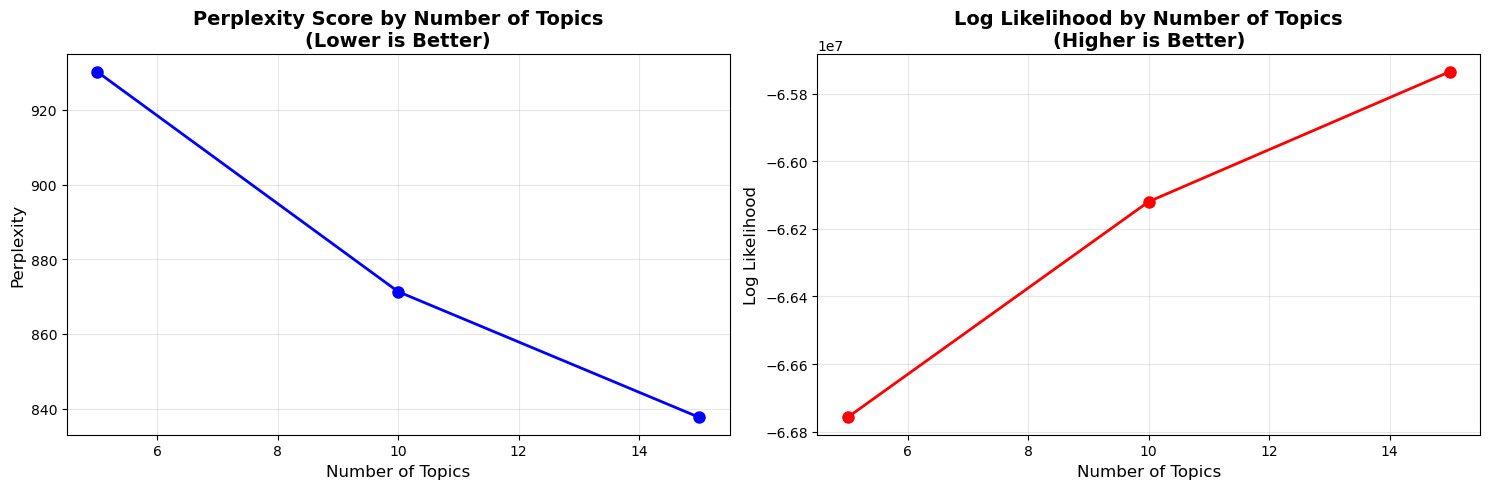


🎯 Optimal number of topics: 15


In [31]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(topic_range, perplexity_vals, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Topics', fontsize=12)
axes[0].set_ylabel('Perplexity', fontsize=12)
axes[0].set_title('Perplexity Score by Number of Topics\n(Lower is Better)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(topic_range, log_likelihood_vals, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Topics', fontsize=12)
axes[1].set_ylabel('Log Likelihood', fontsize=12)
axes[1].set_title('Log Likelihood by Number of Topics\n(Higher is Better)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_topics_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: optimal_topics_analysis.png")
plt.show()

# Find optimal number (where perplexity is lowest)
optimal_idx = np.argmin(perplexity_vals)
optimal_topics = list(topic_range)[optimal_idx]
print(f"\n🎯 Optimal number of topics: {optimal_topics}")

In [32]:
# ============================================================================
# BUILD FINAL LDA MODEL WITH BETTER PARAMETERS
# ============================================================================
print("\n" + "="*60)
print(f"BUILDING LDA MODEL WITH {optimal_topics} TOPICS")
print("="*60)

# Train final model with improved parameters
print("Training LDA model...")
lda_model = LatentDirichletAllocation(
    n_components=optimal_topics,
    random_state=42,
    max_iter=100,          # Increased for better convergence
    learning_method='online',
    learning_decay=0.7,    # For better learning
    doc_topic_prior=0.1,   # Alpha - lower for more focused topics
    topic_word_prior=0.01, # Beta - lower for more specific words
    n_jobs=-1,
    verbose=1
)

lda_output = lda_model.fit_transform(dtm)

print(f"\n✅ Model trained successfully!")
print(f"Perplexity: {lda_model.perplexity(dtm):.2f}")
print(f"Log Likelihood: {lda_model.score(dtm):.2f}")


BUILDING LDA MODEL WITH 15 TOPICS
Training LDA model...
iteration: 1 of max_iter: 100
iteration: 2 of max_iter: 100
iteration: 3 of max_iter: 100
iteration: 4 of max_iter: 100
iteration: 5 of max_iter: 100
iteration: 6 of max_iter: 100
iteration: 7 of max_iter: 100
iteration: 8 of max_iter: 100
iteration: 9 of max_iter: 100
iteration: 10 of max_iter: 100
iteration: 11 of max_iter: 100
iteration: 12 of max_iter: 100
iteration: 13 of max_iter: 100
iteration: 14 of max_iter: 100
iteration: 15 of max_iter: 100
iteration: 16 of max_iter: 100
iteration: 17 of max_iter: 100
iteration: 18 of max_iter: 100
iteration: 19 of max_iter: 100
iteration: 20 of max_iter: 100
iteration: 21 of max_iter: 100
iteration: 22 of max_iter: 100
iteration: 23 of max_iter: 100
iteration: 24 of max_iter: 100
iteration: 25 of max_iter: 100
iteration: 26 of max_iter: 100
iteration: 27 of max_iter: 100
iteration: 28 of max_iter: 100
iteration: 29 of max_iter: 100
iteration: 30 of max_iter: 100
iteration: 31 of max_i

In [33]:
# ============================================================================
# DISPLAY TOP WORDS PER TOPIC
# ============================================================================
print("\n" + "="*60)
print("TOP WORDS FOR EACH TOPIC")
print("="*60)

def display_topics(model, feature_names, no_top_words=20):
    """Display top words for each topic"""
    topic_words = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-no_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topic_words[topic_idx] = top_words
        
        print(f"\n📌 Topic {topic_idx}:")
        print(f"   {', '.join(top_words[:15])}")  # Show first 15 in console
    
    return topic_words

feature_names = vectorizer.get_feature_names_out()
topic_words = display_topics(lda_model, feature_names, no_top_words=20)


TOP WORDS FOR EACH TOPIC

📌 Topic 0:
   police, law, court, violence, officers, crime, drug, state, officer, killed, judge, justice, military, prison, chief

📌 Topic 1:
   housing, residents, community, mayor, development, homes, neighborhoods, neighborhood, council, property, project, plan, buildings, state, apartments

📌 Topic 2:
   voters, clinton, democrats, obama, democratic, republican, vote, states, republicans, white, election, party, state, pennsylvania, polls

📌 Topic 3:
   party, campaign, democratic, election, voters, candidates, vote, candidate, sanders, race, primary, president, mayor, presidential, democrats

📌 Topic 4:
   school, students, schools, college, children, education, university, parents, student, teachers, program, class, state, kids, families

📌 Topic 5:
   party, war, country, power, class, politics, history, french, america, economic, movement, society, americans, france, states

📌 Topic 6:
   workers, tax, jobs, economic, health, labor, pay, economy, mon

Creating word score plots: 100%|██████████| 15/15 [00:00<00:00, 46.44it/s]


✅ Saved: topic_word_scores.png


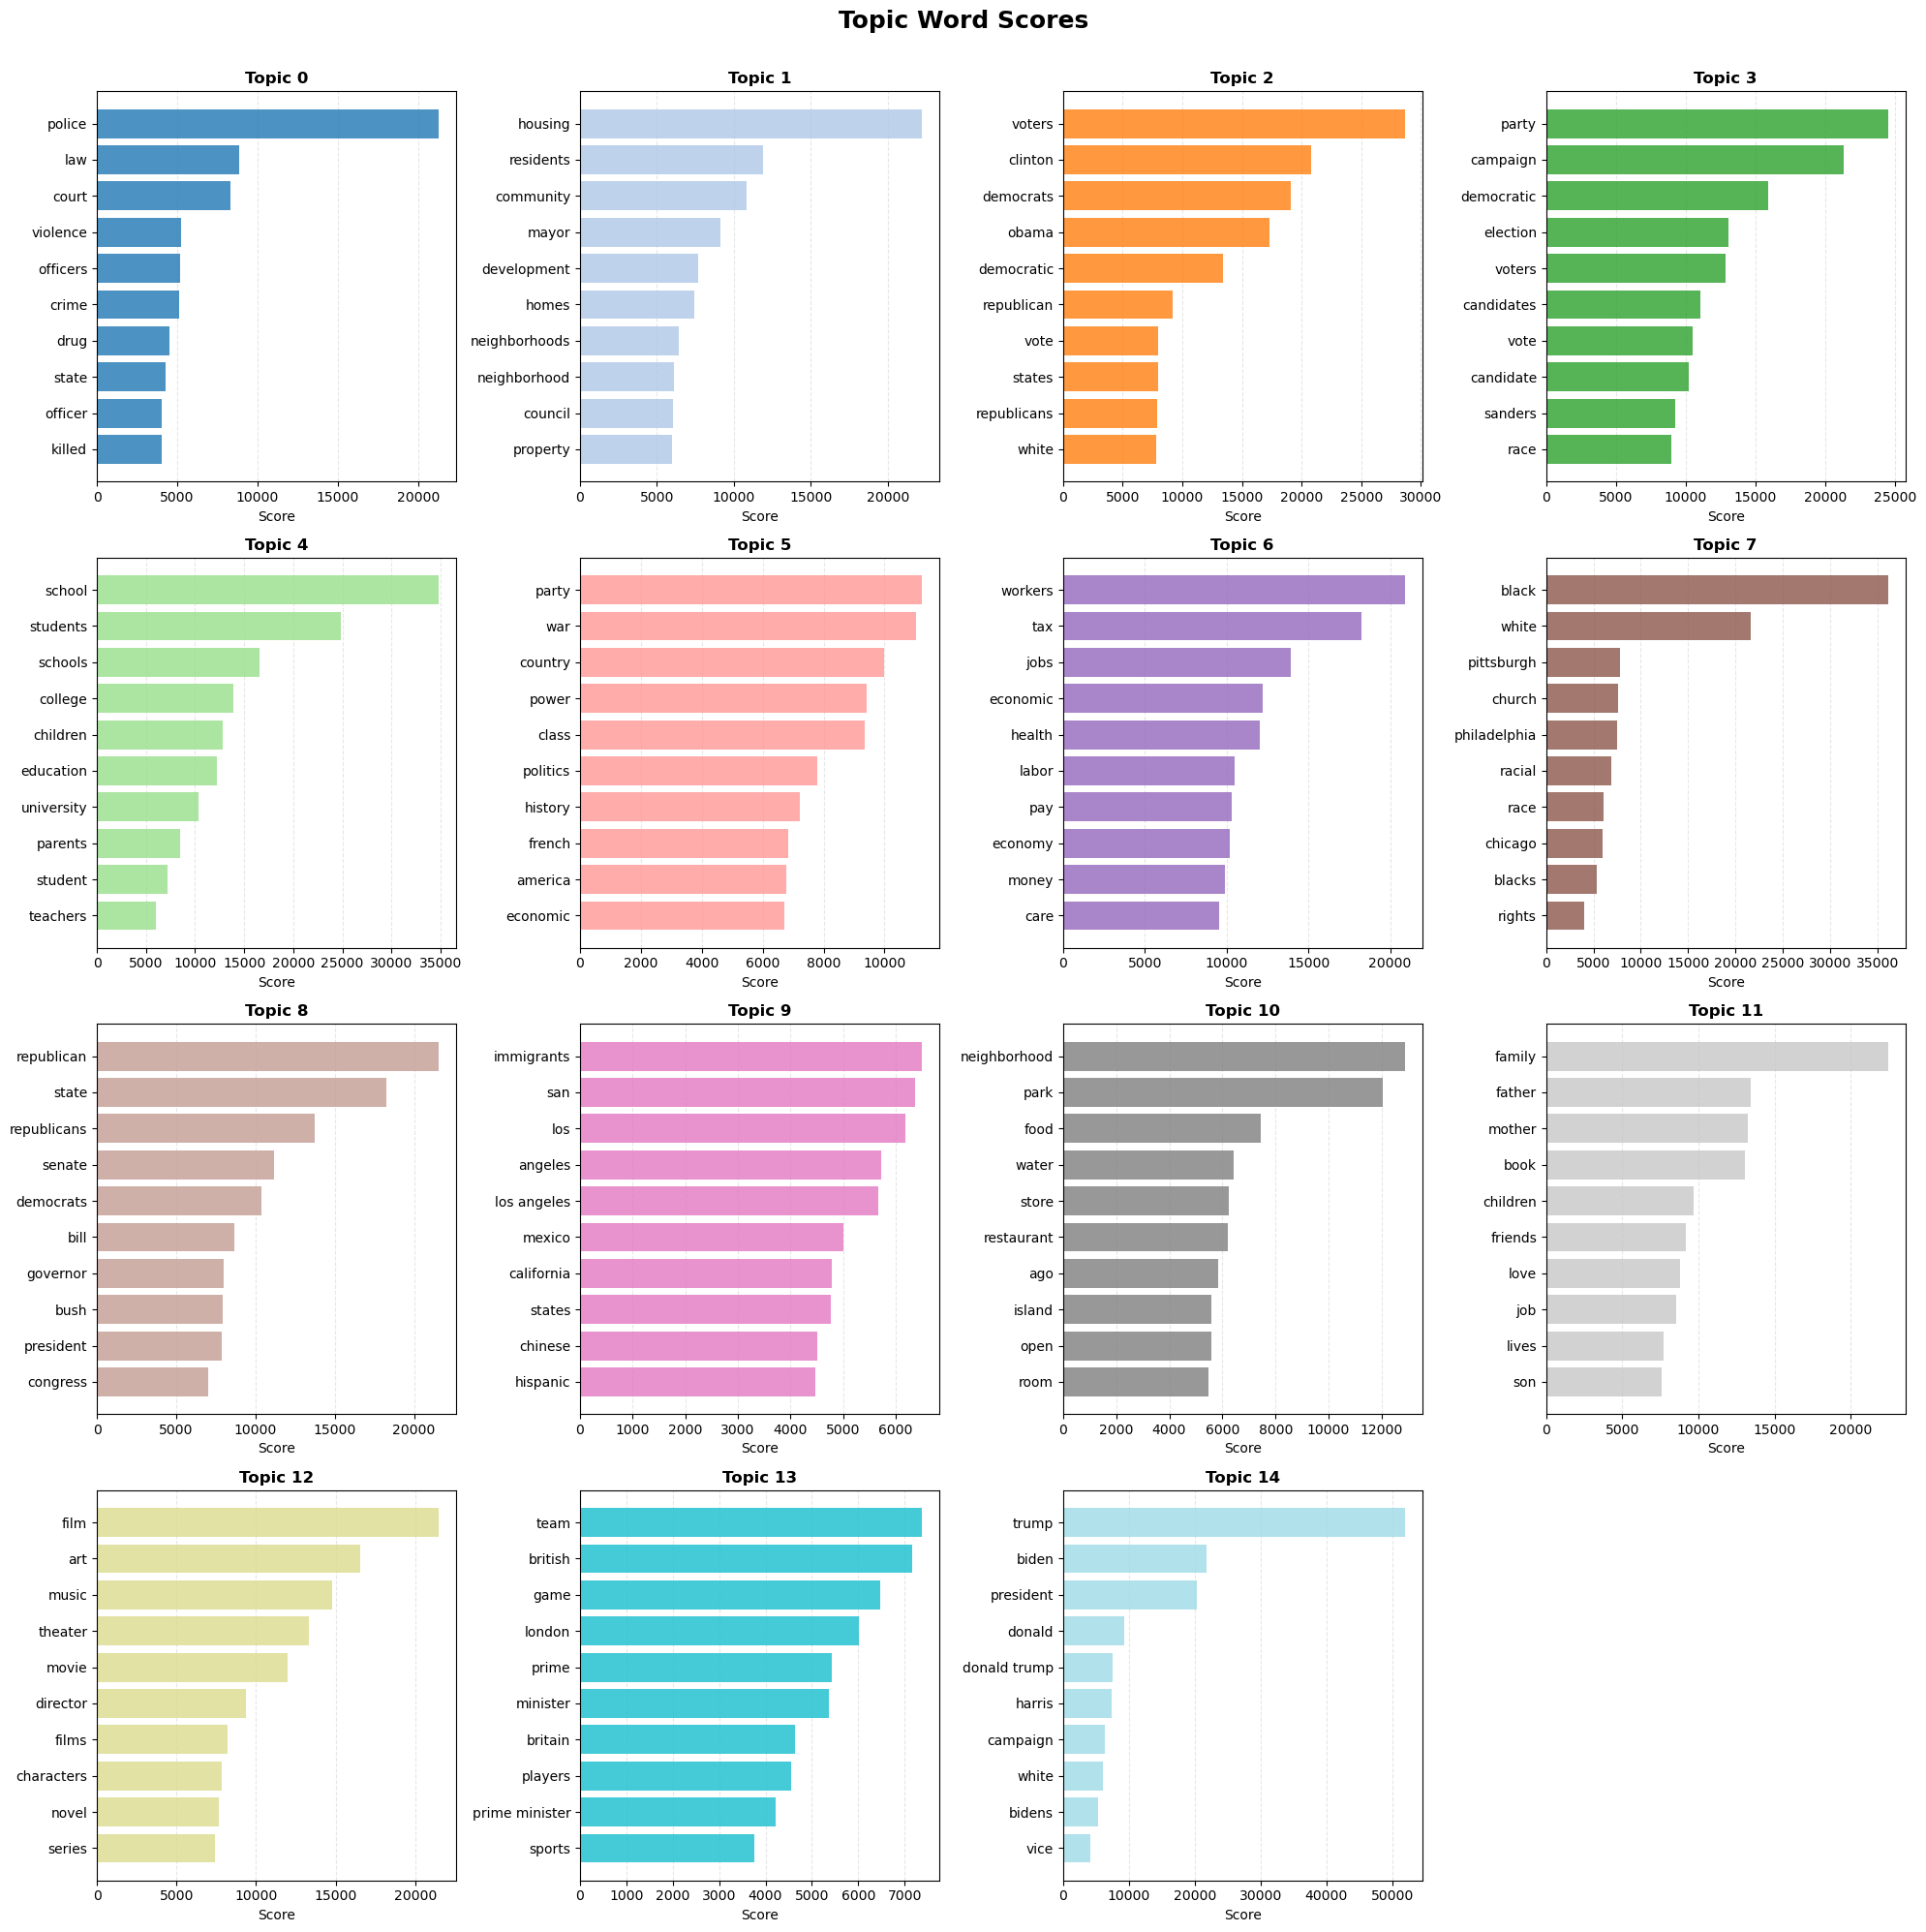

In [35]:
def plot_topic_word_scores(model, feature_names, n_topics, n_words=10):
    """
    Create bar plots showing word scores for each topic
    """
    # Calculate grid dimensions
    cols = 4  # 4 columns
    rows = (n_topics // cols) + (1 if n_topics % cols else 0)
    
    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
    axes = axes.flatten() if n_topics > 1 else [axes]
    
    # Color palette - different color for each topic
    colors = plt.cm.tab20(np.linspace(0, 1, n_topics))
    
    for topic_idx in tqdm(range(n_topics), desc="Creating word score plots"):
        ax = axes[topic_idx]
        
        # Get top words and their scores for this topic
        topic = model.components_[topic_idx]
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = topic[top_indices]
        
        # Reverse for display (highest at top)
        top_words = top_words[::-1]
        top_scores = top_scores[::-1]
        
        # Create horizontal bar chart
        y_pos = np.arange(len(top_words))
        ax.barh(y_pos, top_scores, color=colors[topic_idx], alpha=0.8)
        
        # Customize plot
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_words, fontsize=10)
        ax.set_xlabel('Score', fontsize=10)
        ax.set_title(f'Topic {topic_idx}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # Hide extra subplots
    for idx in range(n_topics, len(axes)):
        axes[idx].axis('off')
    
    # Add main title
    fig.suptitle('Topic Word Scores', fontsize=18, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.savefig('topic_word_scores.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: topic_word_scores.png")
    plt.show()

# Create the visualization
plot_topic_word_scores(lda_model, feature_names, optimal_topics, n_words=10)


TOPIC DISTRIBUTION ANALYSIS
✅ Saved: topic_distribution.png


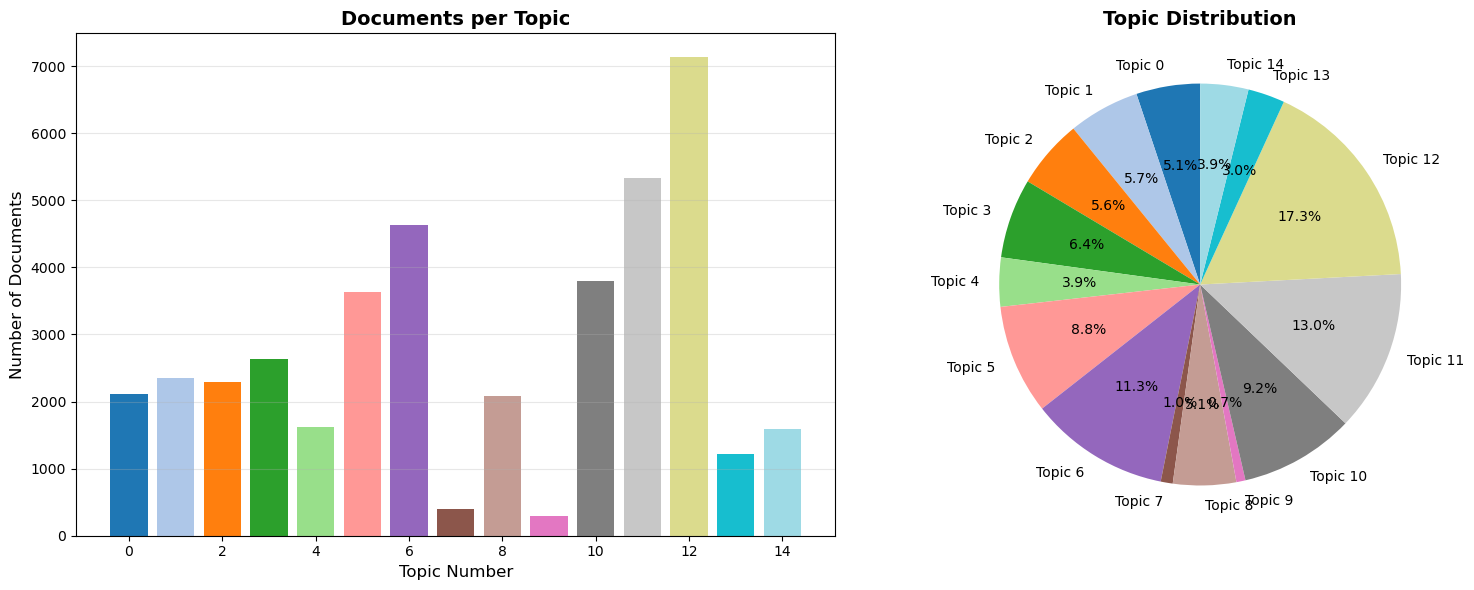

In [44]:
# ============================================================================
# TOPIC DISTRIBUTION ANALYSIS
# ============================================================================
print("\n" + "="*60)
print("TOPIC DISTRIBUTION ANALYSIS")
print("="*60)

# Count documents per topic
topic_counts = df['dominant_topic'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].bar(topic_counts.index, topic_counts.values, color=colors[:len(topic_counts)])
axes[0].set_xlabel('Topic Number', fontsize=12)
axes[0].set_ylabel('Number of Documents', fontsize=12)
axes[0].set_title('Documents per Topic', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(topic_counts.values, labels=[f'Topic {i}' for i in topic_counts.index],
           autopct='%1.1f%%', colors=colors[:len(topic_counts)], startangle=90)
axes[1].set_title('Topic Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: topic_distribution.png")
plt.show()

In [36]:
def save_individual_topic_plots(model, feature_names, n_topics, n_words=15):
    """
    Save individual high-resolution plots for each topic
    Useful for presentations or reports
    """
    import os
    
    # Create directory for individual plots
    os.makedirs('individual_topic_plots', exist_ok=True)
    
    colors = plt.cm.Spectral(np.linspace(0, 1, n_topics))
    
    for topic_idx in tqdm(range(n_topics), desc="Saving individual plots"):
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Get top words and scores
        topic = model.components_[topic_idx]
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = topic[top_indices]
        
        # Reverse for display (highest at top)
        top_words = top_words[::-1]
        top_scores = top_scores[::-1]
        
        # Create horizontal bar chart
        y_pos = np.arange(len(top_words))
        bars = ax.barh(y_pos, top_scores, color=colors[topic_idx], 
                      alpha=0.8, edgecolor='black', linewidth=1)
        
        # Customize
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_words, fontsize=14, fontweight='600')
        ax.set_xlabel('Word Score', fontsize=14, fontweight='bold')
        ax.set_title(f'Topic {topic_idx}: Top {n_words} Words', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=1)
        
        # Add value labels
        for i, (word, score) in enumerate(zip(top_words, top_scores)):
            ax.text(score + max(top_scores)*0.01, i, f'{score:.5f}', 
                   va='center', fontsize=10, fontweight='500')
        
        # Style
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('#fafafa')
        
        plt.tight_layout()
        plt.savefig(f'individual_topic_plots/topic_{topic_idx}_word_scores.png', 
                   dpi=300, bbox_inches='tight', facecolor='white')
        plt.close()
    
    print(f"✅ Saved {n_topics} individual topic plots to 'individual_topic_plots/' folder")

# Save individual plots
save_individual_topic_plots(lda_model, feature_names, optimal_topics, n_words=15)

Saving individual plots: 100%|██████████| 15/15 [00:08<00:00,  1.81it/s]

✅ Saved 15 individual topic plots to 'individual_topic_plots/' folder


Creating word clouds: 100%|██████████| 15/15 [00:03<00:00,  4.24it/s]


✅ Saved: topic_wordclouds.png


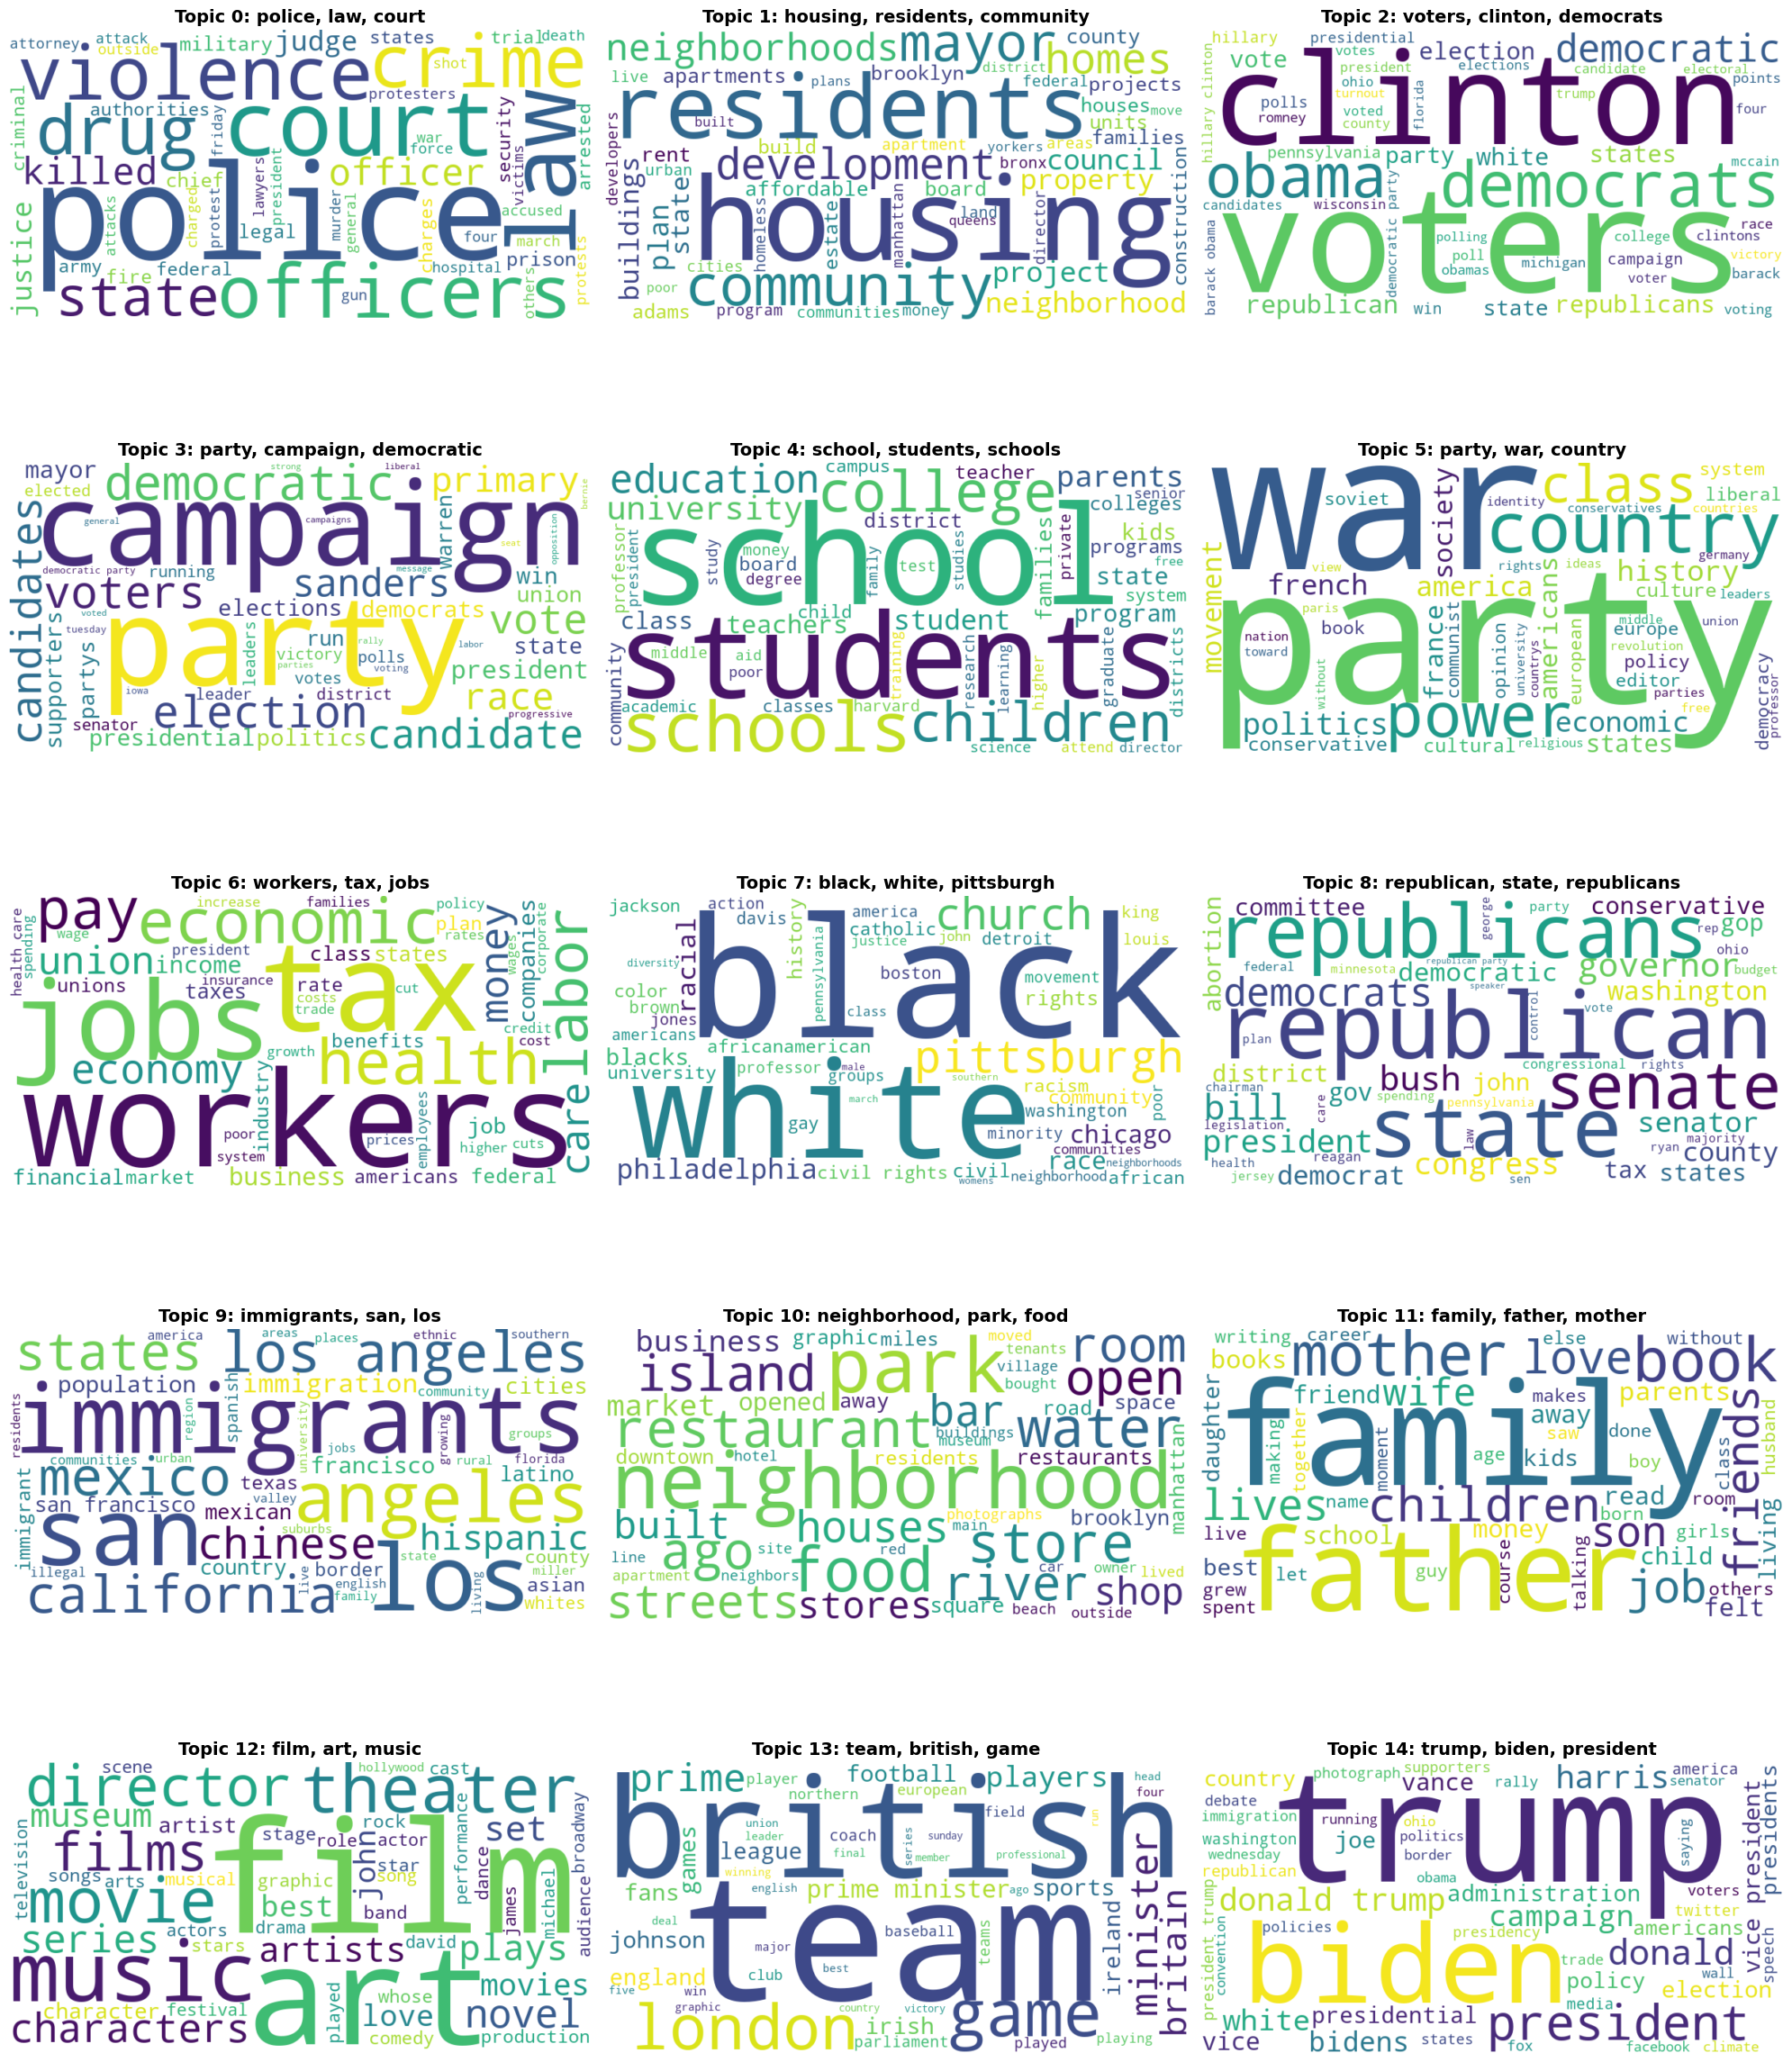

In [37]:
# Create word clouds
n_topics = optimal_topics
cols = 3
rows = (n_topics // cols) + (1 if n_topics % cols else 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten() if n_topics > 1 else [axes]

colors = plt.cm.tab20(np.linspace(0, 1, n_topics))

for topic_idx in tqdm(range(n_topics), desc="Creating word clouds"):
    # Get word weights for this topic
    topic = lda_model.components_[topic_idx]
    word_freq = {feature_names[i]: topic[i] for i in range(len(feature_names))}
    
    # Create word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10,
        max_words=50
    ).generate_from_frequencies(word_freq)
    
    # Plot
    axes[topic_idx].imshow(wordcloud, interpolation='bilinear')
    axes[topic_idx].set_title(f'Topic {topic_idx}: {", ".join(topic_words[topic_idx][:3])}', 
                             fontsize=14, fontweight='bold')
    axes[topic_idx].axis('off')

# Hide extra subplots
for idx in range(n_topics, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('topic_wordclouds.png', dpi=300, bbox_inches='tight')
print("✅ Saved: topic_wordclouds.png")
plt.show()

In [38]:
# ============================================================================
# ASSIGN DOMINANT TOPIC TO EACH DOCUMENT
# ============================================================================
print("\n" + "="*60)
print("ASSIGNING TOPICS TO DOCUMENTS")
print("="*60)

# Get dominant topic for each document
df['dominant_topic'] = lda_output.argmax(axis=1)
df['topic_probability'] = lda_output.max(axis=1)

# Add top words for each document's dominant topic
df['topic_keywords'] = df['dominant_topic'].apply(
    lambda x: ', '.join(topic_words[x][:5])
)

print("\nSample topic assignments:")
print(df[['title', 'dominant_topic', 'topic_probability', 'topic_keywords']].head(10))


ASSIGNING TOPICS TO DOCUMENTS

Sample topic assignments:
                                               title  dominant_topic  \
0  A Well-Documented Childhood. A Very Private Life.              11   
1  These were the big stories in arts and culture...              12   
2                    She Exalted The Beauty Of Dance              12   
3  Under a Highway in Rio, a Dance Style Charms a...              12   
4  Congressional pay, minimum wage stagnant for y...               6   
5  Amy Carter, Thrust Into the Public Eye at a Yo...              11   
6  Democratic N.Y. Lawmakers Brace for Risks of a...               8   
7  Arlene Croce Elevated Dance Criticism With Sty...              12   
8        Crash, Burn, Repeat: A Pop Star's Spectacle              12   
9         SHERROD BROWN KNOWS WHY THE DEMOCRATS LOST               8   

   topic_probability                                     topic_keywords  
0           0.421452             family, father, mother, book, children  
1


TOPIC-CATEGORY ANALYSIS
✅ Saved: topic_category_heatmap.png


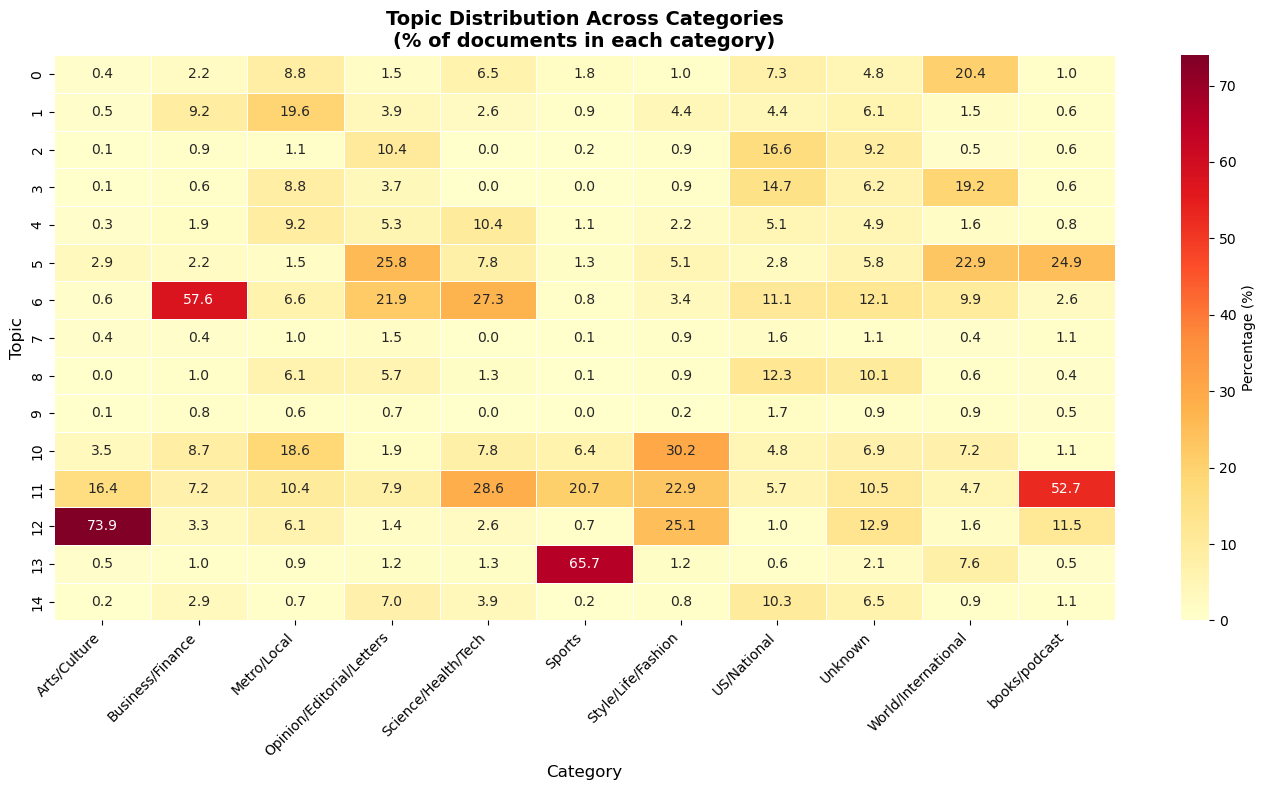


Topic-Category Distribution:
category        Arts/Culture  Business/Finance  Metro/Local  \
dominant_topic                                                
0                        0.4               2.2          8.8   
1                        0.5               9.2         19.6   
2                        0.1               0.9          1.1   
3                        0.1               0.6          8.8   
4                        0.3               1.9          9.2   
5                        2.9               2.2          1.5   
6                        0.6              57.6          6.6   
7                        0.4               0.4          1.0   
8                        0.0               1.0          6.1   
9                        0.1               0.8          0.6   
10                       3.5               8.7         18.6   
11                      16.4               7.2         10.4   
12                      73.9               3.3          6.1   
13                       

In [39]:
# ============================================================================
# TOPIC-CATEGORY HEATMAP
# ============================================================================
print("\n" + "="*60)
print("TOPIC-CATEGORY ANALYSIS")
print("="*60)

if 'category' in df.columns:
    # Create cross-tabulation
    topic_category = pd.crosstab(
        df['dominant_topic'],
        df['category'].fillna('Unknown'),
        normalize='columns'
    ) * 100  # Convert to percentages
    
    # Plot heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        topic_category,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Percentage (%)'},
        linewidths=0.5,
        vmin=0,
        vmax=topic_category.max().max()
    )
    plt.title('Topic Distribution Across Categories\n(% of documents in each category)',
             fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Topic', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('topic_category_heatmap.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: topic_category_heatmap.png")
    plt.show()
    
    # Print summary statistics
    print("\nTopic-Category Distribution:")
    print(topic_category.round(1))

In [40]:
# ============================================================================
# ADDITIONAL: TOP DOCUMENTS PER TOPIC
# ============================================================================
print("\n" + "="*60)
print("TOP DOCUMENTS PER TOPIC (Sample)")
print("="*60)

for topic_idx in range(min(5, optimal_topics)):  # Show first 5 topics
    print(f"\n{'='*60}")
    print(f"📌 Topic {topic_idx}: {', '.join(topic_words[topic_idx][:5])}")
    print('='*60)
    
    # Get top 3 documents for this topic
    topic_docs = df[df['dominant_topic'] == topic_idx].nlargest(3, 'topic_probability')
    
    for idx, row in topic_docs.iterrows():
        print(f"\n  • {row['title']}")
        print(f"    Probability: {row['topic_probability']:.3f}")
        if 'category' in df.columns:
            print(f"    Category: {row['category']}")


TOP DOCUMENTS PER TOPIC (Sample)

📌 Topic 0: police, law, court, violence, officers

  • VICTIM OF FIREHOUSE SEX BIAS CHARGED IN A VIRGINIA ARSON
    Probability: 0.884
    Category: Metro/Local

  • World News Briefs;
Murder Charge Dropped In Mexico Assault Case
    Probability: 0.881
    Category: World/International

  • U.S. Soldiers Accused of Shooting Civilians in Sadr City - Correction Appended
    Probability: 0.873
    Category: World/International

📌 Topic 1: housing, residents, community, mayor, development

  • New York City May Pay You to Build a 'Granny Flat' in Your Backyard
    Probability: 0.934
    Category: Metro/Local

  • New York City Might Pay You to Construct or Retrofit a 'Granny Flat' in Your Backyard
    Probability: 0.931
    Category: US/National

  • New York Secures the Most Affordable Housing Units in 27 Years
    Probability: 0.930
    Category: Metro/Local

📌 Topic 2: voters, clinton, democrats, obama, democratic

  • Dip in Democratic Voter Lead Migh


TOPIC EVOLUTION OVER TIME
✅ Saved: topic_evolution_over_time.png


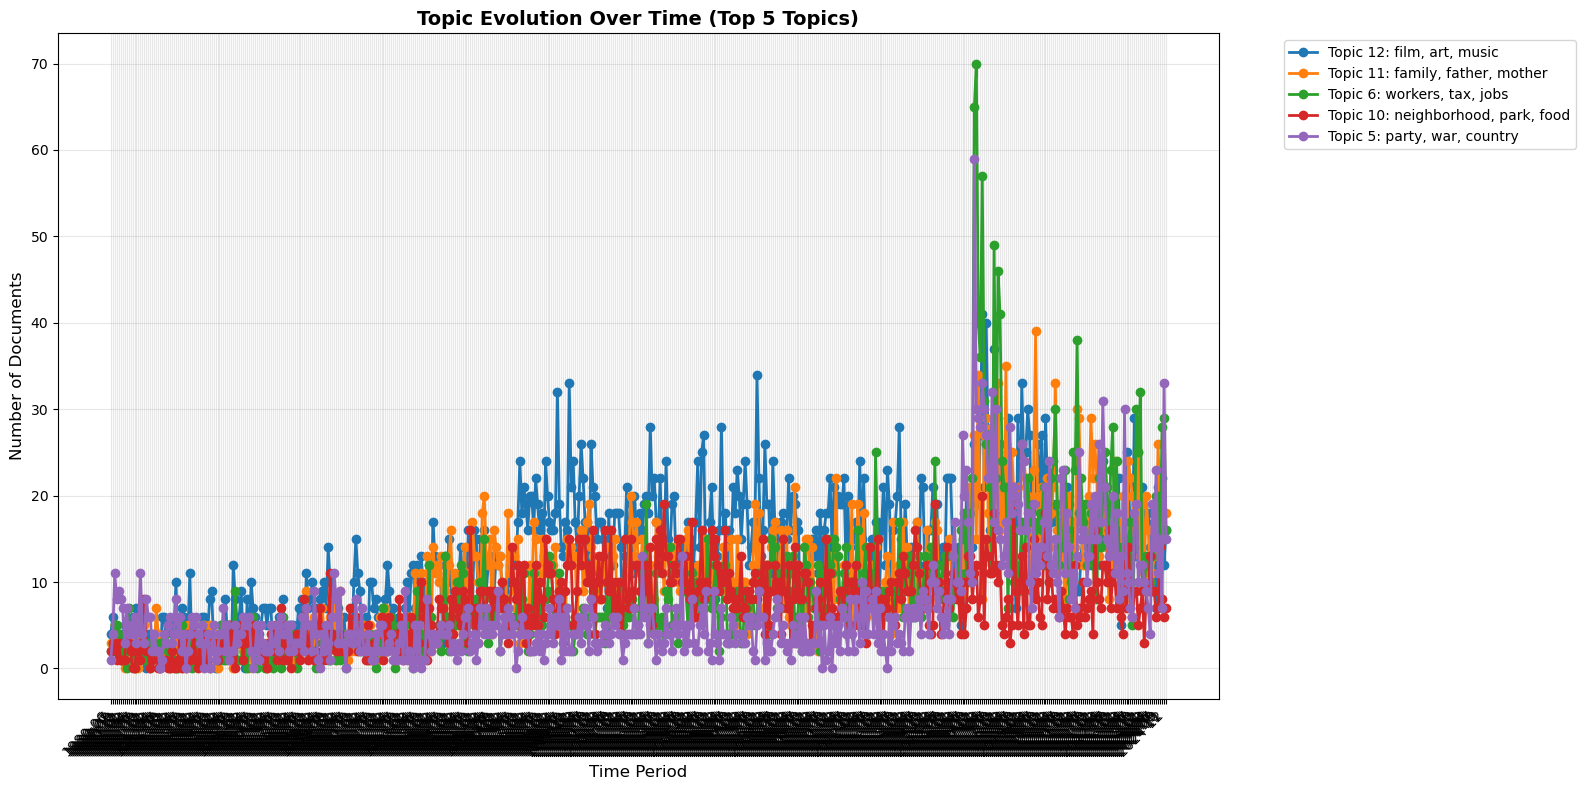

In [41]:
# ============================================================================
# TOPIC EVOLUTION OVER TIME (if date column exists)
# ============================================================================
print("\n" + "="*60)
print("TOPIC EVOLUTION OVER TIME")
print("="*60)

if 'date' in df.columns:
    try:
        # Convert date to datetime
        df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
        df_with_dates = df[df['date_parsed'].notna()].copy()
        
        if len(df_with_dates) > 0:
            # Extract year-month
            df_with_dates['year_month'] = df_with_dates['date_parsed'].dt.to_period('M')
            
            # Count topics per month
            topic_time = pd.crosstab(
                df_with_dates['year_month'],
                df_with_dates['dominant_topic']
            )
            
            # Plot topic evolution
            plt.figure(figsize=(16, 8))
            
            # Select top 5 most common topics
            top_topics = df['dominant_topic'].value_counts().head(5).index
            
            for topic_idx in top_topics:
                if topic_idx in topic_time.columns:
                    plt.plot(topic_time.index.astype(str), 
                           topic_time[topic_idx], 
                           marker='o', 
                           linewidth=2,
                           label=f'Topic {topic_idx}: {", ".join(topic_words[topic_idx][:3])}')
            
            plt.xlabel('Time Period', fontsize=12)
            plt.ylabel('Number of Documents', fontsize=12)
            plt.title('Topic Evolution Over Time (Top 5 Topics)', fontsize=14, fontweight='bold')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.savefig('topic_evolution_over_time.png', dpi=300, bbox_inches='tight')
            print("✅ Saved: topic_evolution_over_time.png")
            plt.show()
        else:
            print("⚠️  No valid dates found for time evolution analysis")
    except Exception as e:
        print(f"⚠️  Could not create time evolution plot: {e}")
else:
    print("⚠️  No 'date' column found - skipping time evolution analysis")


CALCULATING TOPIC COHERENCE


Calculating coherence: 100%|██████████| 15/15 [00:00<00:00, 28.10it/s]


✅ Saved: topic_coherence_scores.png


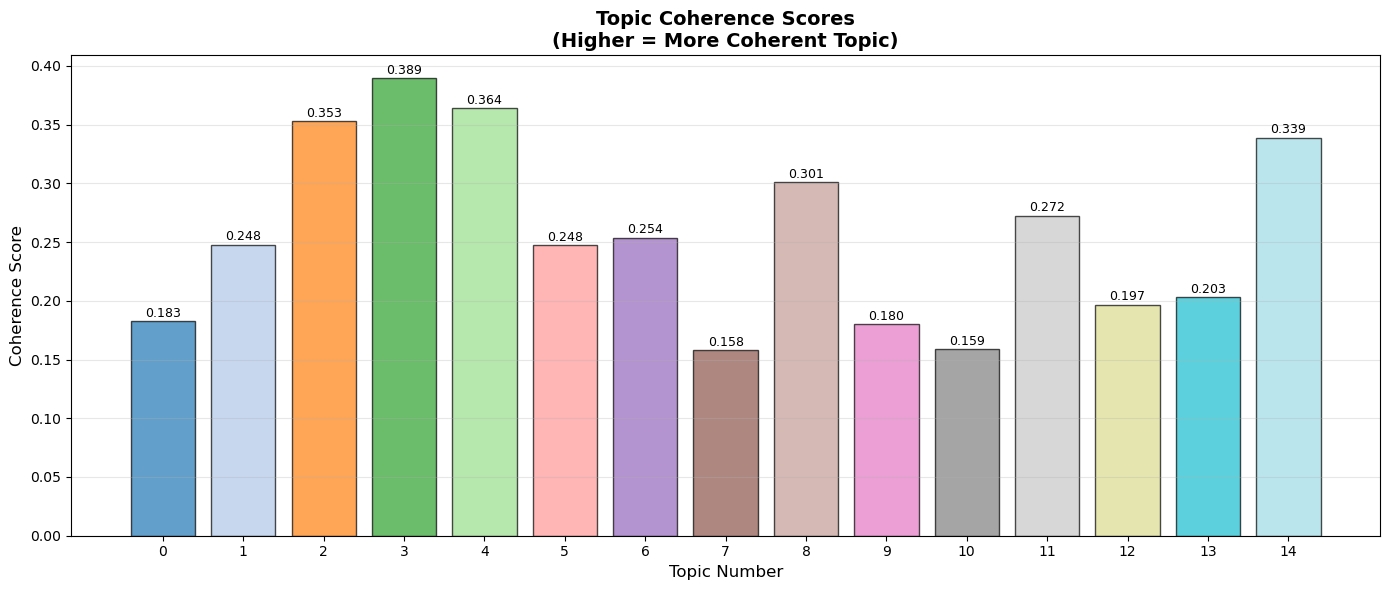


Coherence Scores by Topic:
  Topic 0: 0.1829 - police, law, court
  Topic 1: 0.2478 - housing, residents, community
  Topic 2: 0.3529 - voters, clinton, democrats
  Topic 3: 0.3894 - party, campaign, democratic
  Topic 4: 0.3639 - school, students, schools
  Topic 5: 0.2475 - party, war, country
  Topic 6: 0.2538 - workers, tax, jobs
  Topic 7: 0.1580 - black, white, pittsburgh
  Topic 8: 0.3009 - republican, state, republicans
  Topic 9: 0.1802 - immigrants, san, los
  Topic 10: 0.1586 - neighborhood, park, food
  Topic 11: 0.2725 - family, father, mother
  Topic 12: 0.1967 - film, art, music
  Topic 13: 0.2028 - team, british, game
  Topic 14: 0.3389 - trump, biden, president


In [42]:
# ============================================================================
# TOPIC COHERENCE SCORES
# ============================================================================
print("\n" + "="*60)
print("CALCULATING TOPIC COHERENCE")
print("="*60)

def calculate_topic_coherence(model, dtm, feature_names, n_top_words=10):
    """
    Calculate coherence score for each topic based on word co-occurrence
    """
    from sklearn.metrics.pairwise import cosine_similarity
    
    coherence_scores = []
    
    for topic_idx in tqdm(range(model.n_components), desc="Calculating coherence"):
        topic = model.components_[topic_idx]
        top_indices = topic.argsort()[-n_top_words:][::-1]
        
        # Get vectors for top words
        word_vectors = dtm[:, top_indices].toarray()
        
        # Calculate pairwise cosine similarity
        similarity_matrix = cosine_similarity(word_vectors.T)
        
        # Average similarity (excluding diagonal)
        mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
        coherence = similarity_matrix[mask].mean()
        coherence_scores.append(coherence)
    
    return coherence_scores

coherence_scores = calculate_topic_coherence(lda_model, dtm, feature_names, n_top_words=10)

# Plot coherence scores
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(coherence_scores)), coherence_scores, 
              color=colors[:len(coherence_scores)], alpha=0.7, edgecolor='black')
plt.xlabel('Topic Number', fontsize=12)
plt.ylabel('Coherence Score', fontsize=12)
plt.title('Topic Coherence Scores\n(Higher = More Coherent Topic)', 
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(len(coherence_scores)))

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, coherence_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
            f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('topic_coherence_scores.png', dpi=300, bbox_inches='tight')
print("✅ Saved: topic_coherence_scores.png")
plt.show()

print("\nCoherence Scores by Topic:")
for idx, score in enumerate(coherence_scores):
    print(f"  Topic {idx}: {score:.4f} - {', '.join(topic_words[idx][:3])}")


In [43]:
# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save enhanced dataframe
output_columns = ['title', 'body', 'category', 'publisher', 'date', 
                 'dominant_topic', 'topic_probability', 'topic_keywords']
output_columns = [col for col in output_columns if col in df.columns]

df[output_columns].to_csv('articles_with_topics.csv', index=False)
print("✅ Saved: articles_with_topics.csv")

# Save topic words with coherence scores
topic_words_df = pd.DataFrame([
    {
        'topic': idx, 
        'top_20_words': ', '.join(words),
        'coherence_score': coherence_scores[idx],
        'num_documents': len(df[df['dominant_topic'] == idx])
    }
    for idx, words in topic_words.items()
])
topic_words_df.to_csv('topic_keywords.csv', index=False)
print("✅ Saved: topic_keywords.csv")

# Save topic-document matrix
topic_doc_df = pd.DataFrame(
    lda_output,
    columns=[f'topic_{i}_prob' for i in range(optimal_topics)]
)
topic_doc_df.to_csv('topic_document_matrix.csv', index=False)
print("✅ Saved: topic_document_matrix.csv")

# Save model summary
with open('model_summary.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("LDA TOPIC MODELING - MODEL SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write(f"Total documents analyzed: {len(df)}\n")
    f.write(f"Optimal number of topics: {optimal_topics}\n")
    f.write(f"Vocabulary size: {len(feature_names)}\n")
    f.write(f"Model perplexity: {lda_model.perplexity(dtm):.2f}\n")
    f.write(f"Model log likelihood: {lda_model.score(dtm):.2f}\n")
    f.write(f"Average topic probability: {df['topic_probability'].mean():.3f}\n")
    f.write(f"Custom stopwords count: {len(custom_stops)}\n\n")
    
    f.write("="*60 + "\n")
    f.write("TOPIC DETAILS\n")
    f.write("="*60 + "\n\n")
    
    for idx in range(optimal_topics):
        f.write(f"\nTopic {idx}:\n")
        f.write(f"  Keywords: {', '.join(topic_words[idx][:10])}\n")
        f.write(f"  Coherence Score: {coherence_scores[idx]:.4f}\n")
        f.write(f"  Number of Documents: {len(df[df['dominant_topic'] == idx])}\n")
        f.write(f"  Percentage: {len(df[df['dominant_topic'] == idx])/len(df)*100:.2f}%\n")

print("✅ Saved: model_summary.txt")

# ============================================================================
# CREATE INTERACTIVE HTML REPORT (BONUS)
# ============================================================================
print("\n" + "="*60)
print("CREATING HTML REPORT")
print("="*60)

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>LDA Topic Modeling Report</title>
    <style>
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        h1 {{
            color: #2c3e50;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
        }}
        h2 {{
            color: #34495e;
            margin-top: 30px;
        }}
        .summary {{
            background-color: white;
            padding: 20px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            margin-bottom: 20px;
        }}
        .topic {{
            background-color: white;
            padding: 15px;
            margin-bottom: 15px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            border-left: 4px solid #3498db;
        }}
        .metric {{
            display: inline-block;
            background-color: #ecf0f1;
            padding: 10px 15px;
            margin: 5px;
            border-radius: 5px;
            font-weight: bold;
        }}
        .keywords {{
            color: #2980b9;
            font-style: italic;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            background-color: white;
            margin-top: 15px;
        }}
        th, td {{
            padding: 12px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }}
        th {{
            background-color: #3498db;
            color: white;
        }}
        tr:hover {{
            background-color: #f5f5f5;
        }}
    </style>
</head>
<body>
    <h1>📊 LDA Topic Modeling Report</h1>
    
    <div class="summary">
        <h2>Model Summary</h2>
        <div class="metric">Documents: {len(df)}</div>
        <div class="metric">Topics: {optimal_topics}</div>
        <div class="metric">Vocabulary: {len(feature_names)}</div>
        <div class="metric">Perplexity: {lda_model.perplexity(dtm):.2f}</div>
        <div class="metric">Avg. Probability: {df['topic_probability'].mean():.3f}</div>
    </div>
    
    <h2>📌 Topic Details</h2>
"""

for idx in range(optimal_topics):
    num_docs = len(df[df['dominant_topic'] == idx])
    percentage = num_docs / len(df) * 100
    
    html_content += f"""
    <div class="topic">
        <h3>Topic {idx}</h3>
        <p><strong>Keywords:</strong> <span class="keywords">{', '.join(topic_words[idx][:10])}</span></p>
        <p><strong>Coherence Score:</strong> {coherence_scores[idx]:.4f}</p>
        <p><strong>Documents:</strong> {num_docs} ({percentage:.2f}%)</p>
    </div>
    """

html_content += """
    <h2>📄 Top Documents by Topic (First 3 Topics)</h2>
"""

for topic_idx in range(min(3, optimal_topics)):
    topic_docs = df[df['dominant_topic'] == topic_idx].nlargest(5, 'topic_probability')
    
    html_content += f"""
    <h3>Topic {topic_idx}: {', '.join(topic_words[topic_idx][:3])}</h3>
    <table>
        <tr>
            <th>Title</th>
            <th>Probability</th>
            <th>Category</th>
        </tr>
    """
    
    for _, row in topic_docs.iterrows():
        category = row.get('category', 'N/A')
        html_content += f"""
        <tr>
            <td>{row['title']}</td>
            <td>{row['topic_probability']:.3f}</td>
            <td>{category}</td>
        </tr>
        """
    
    html_content += "</table>"

html_content += """
</body>
</html>
"""

with open('topic_modeling_report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ Saved: topic_modeling_report.html")

# ============================================================================
# SUMMARY REPORT
# ============================================================================
print("\n" + "="*60)
print("📊 FINAL SUMMARY REPORT")
print("="*60)
print(f"✅ Total documents analyzed: {len(df)}")
print(f"✅ Optimal number of topics: {optimal_topics}")
print(f"✅ Vocabulary size: {len(feature_names)}")
print(f"✅ Model perplexity: {lda_model.perplexity(dtm):.2f}")
print(f"✅ Model log likelihood: {lda_model.score(dtm):.2f}")
print(f"✅ Average topic probability: {df['topic_probability'].mean():.3f}")
print(f"✅ Average coherence score: {np.mean(coherence_scores):.4f}")
print(f"✅ Custom stopwords added: {len(custom_stops)}")

print("\n📊 Documents per Topic:")
for idx in range(optimal_topics):
    num_docs = len(df[df['dominant_topic'] == idx])
    percentage = num_docs / len(df) * 100
    print(f"  Topic {idx}: {num_docs} documents ({percentage:.2f}%)")

print("\n📁 Files created:")
print("   • optimal_topics_analysis.png")
print("   • topic_word_scores.png")
print("   • topic_word_scores_combined.png")
print("   • individual_topic_plots/ (folder with individual plots)")
print("   • topic_wordclouds.png")
print("   • topic_distribution.png")
print("   • topic_category_heatmap.png")
print("   • topic_evolution_over_time.png (if dates available)")
print("   • topic_coherence_scores.png")
print("   • articles_with_topics.csv")
print("   • topic_keywords.csv")
print("   • topic_document_matrix.csv")
print("   • model_summary.txt")
print("   • topic_modeling_report.html")

print("\n✨ Topic modeling complete with all visualizations and analysis!")
print("="*60)

# ============================================================================
# ADDITIONAL STATISTICS
# ============================================================================
print("\n" + "="*60)
print("📈 ADDITIONAL STATISTICS")
print("="*60)

print("\n🎯 Most Coherent Topics:")
top_coherent = np.argsort(coherence_scores)[-5:][::-1]
for rank, idx in enumerate(top_coherent, 1):
    print(f"  {rank}. Topic {idx} (Score: {coherence_scores[idx]:.4f})")
    print(f"     Keywords: {', '.join(topic_words[idx][:5])}")

print("\n📚 Largest Topics:")
largest_topics = df['dominant_topic'].value_counts().head(5)
for rank, (topic_idx, count) in enumerate(largest_topics.items(), 1):
    percentage = count / len(df) * 100
    print(f"  {rank}. Topic {topic_idx}: {count} documents ({percentage:.2f}%)")
    print(f"     Keywords: {', '.join(topic_words[topic_idx][:5])}")

if 'category' in df.columns:
    print("\n🏷️  Topic Distribution by Category:")
    for category in df['category'].dropna().unique()[:5]:
        cat_df = df[df['category'] == category]
        top_topic = cat_df['dominant_topic'].mode()[0] if len(cat_df) > 0 else 'N/A'
        print(f"  {category}: Most common topic = Topic {top_topic}")

print("\n" + "="*60)
print("🎉 ALL DONE! Check the output files for detailed results.")
print("="*60)


SAVING RESULTS
✅ Saved: articles_with_topics.csv
✅ Saved: topic_keywords.csv
✅ Saved: topic_document_matrix.csv


python(30224) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30225) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30226) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30228) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30229) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30230) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30231) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


NameError: name 'custom_stops' is not defined

In [ ]:
print(df.loc[df['dominant_topic'] == 0]['body'].iloc[0])

Exception ignored in: <function ResourceTracker.__del__ at 0x102989b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105495b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1073ddb20>
Traceback (most recent call last

In [49]:
!pip install torch torchvision torchaudio
!pip install sentence-transformers
!pip install hdbscan
!pip install bertopic
!pip install plotly kaleido

python(31199) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch


python(31205) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached sentence_transformers-5.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-4.57.0-py3-none-any.whl.metadata (41 kB)
INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
  Using cached sentence_transformers-5.1.0-py3-none-any.whl.metadata (16 kB)
  Using cached sentence_transformers-5.0.0-py3-none-any.whl.metadata (16 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.2-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.1-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.0-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-3.4.1-py3-none-any.whl.metadata (10 kB)
INFO: pip is still looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a 

python(31273) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(31285) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached bertopic-0.17.3-py3-none-any.whl.metadata (24 kB)
  Using cached sentence_transformers-5.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-4.57.0-py3-none-any.whl.metadata (41 kB)
INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
  Using cached sentence_transformers-5.1.0-py3-none-any.whl.metadata (16 kB)
  Using cached sentence_transformers-5.0.0-py3-none-any.whl.metadata (16 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.2-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.1-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.0-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-3.4.1-py3-none-any.whl.metadata (10 kB)
INFO: pip is still looking at multiple versions of sentence-transformers to determine which 

python(31326) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached kaleido-1.1.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached orjson-3.11.3-cp313-cp313-macosx_10_15_x86_64.macosx_11_0_arm64.macosx_10_15_universal2.whl.metadata (41 kB)
  Using cached pytest_timeout-2.4.0-py3-none-any.whl.metadata (20 kB)
  Using cached simplejson-3.20.2-cp313-cp313-macosx_10_13_x86_64.whl.metadata (3.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [kaleido]m5/6 [kaleido]


In [46]:
# ============================================================================
# BERTOPIC IMPLEMENTATION - BETTER THAN LDA FOR NEWS ARTICLES
# ============================================================================

print("\n" + "="*80)
print("BERTOPIC")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# BERTopic imports
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer


BERTOPIC


python(30712) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached bertopic-0.17.3-py3-none-any.whl.metadata (24 kB)
  Using cached sentence_transformers-5.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached umap_learn-0.5.9.post2-py3-none-any.whl.metadata (25 kB)
  Using cached hdbscan-0.8.40.tar.gz (6.9 MB)
  Installing build dependencies ..done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached transformers-4.57.0-py3-none-any.whl.metadata (41 kB)
INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
  Using cached sentence_transformers-5.1.0-py3-none-any.whl.metadata (16 kB)
  Using cached sentence_transformers-5.0.0-py3-none-any.whl.metadata (16 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.2-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.1-py3-none-any.whl.metadata (13

ModuleNotFoundError: No module named 'bertopic'

In [ ]:
# ============================================================================
# STEP 1: PREPARE DATA
# ============================================================================
documents = (df['title'].fillna('') + ' ' + df['body'].fillna('')).tolist()

print(f"✅ Prepared {len(documents)} documents")


In [ ]:
# ============================================================================
# STEP 2: CONFIGURE BERTOPIC WITH OPTIMAL SETTINGS
# ============================================================================
print("\n" + "="*60)
print("CONFIGURING BERTOPIC")
print("="*60)

# 1. Sentence embedding model (converts text to vectors)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Loaded embedding model: all-MiniLM-L6-v2")

# 2. UMAP for dimensionality reduction
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# 3. HDBSCAN for clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=50,        # ⭐ Adjust for topic size (lower = more topics)
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# 4. Vectorizer (with your custom stopwords)
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5,
    max_df=0.7
)

# Add custom stopwords
custom_stops_list = list(custom_stops)
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=custom_stops_list,
    min_df=5,
    max_df=0.7
)

# 5. Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    language='english',
    calculate_probabilities=True,
    verbose=True
)

print("✅ BERTopic model configured")

In [45]:





# ============================================================================
# STEP 3: FIT BERTOPIC MODEL
# ============================================================================
print("\n" + "="*60)
print("FITTING BERTOPIC MODEL (This may take a few minutes...)")
print("="*60)

# Fit the model
topics, probs = topic_model.fit_transform(documents)

print(f"\n✅ BERTopic completed!")
print(f"   • Found {len(set(topics))} topics (including outliers)")
print(f"   • Topic -1 = outliers ({sum(topics == -1)} documents)")
print(f"   • Valid topics: {len(set(topics)) - 1}")

# ============================================================================
# STEP 4: ADD BERTOPIC RESULTS TO DATAFRAME
# ============================================================================
print("\n" + "="*60)
print("ADDING BERTOPIC RESULTS TO DATAFRAME")
print("="*60)

df['bertopic_topic'] = topics
df['bertopic_probability'] = [max(prob) if len(prob) > 0 else 0 for prob in probs]

# Get topic info
topic_info = topic_model.get_topic_info()
print("\n📊 Topic Overview:")
print(topic_info[['Topic', 'Count', 'Name']].head(20))

# ============================================================================
# STEP 5: VISUALIZE TOPICS
# ============================================================================
print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

# 1. Topic visualization (interactive)
print("\n1️⃣ Creating topic visualization...")
fig = topic_model.visualize_topics()
fig.write_html('bertopic_topics_visualization.html')
print("✅ Saved: bertopic_topics_visualization.html")

# 2. Topic hierarchy
print("\n2️⃣ Creating topic hierarchy...")
fig = topic_model.visualize_hierarchy()
fig.write_html('bertopic_hierarchy.html')
print("✅ Saved: bertopic_hierarchy.html")

# 3. Topic barchart (top 10 topics)
print("\n3️⃣ Creating topic barchart...")
fig = topic_model.visualize_barchart(top_n_topics=15, n_words=10)
fig.write_html('bertopic_barchart.html')
print("✅ Saved: bertopic_barchart.html")

# 4. Heatmap
print("\n4️⃣ Creating topic heatmap...")
fig = topic_model.visualize_heatmap(n_clusters=20)
fig.write_html('bertopic_heatmap.html')
print("✅ Saved: bertopic_heatmap.html")

# ============================================================================
# STEP 6: DISPLAY TOPIC KEYWORDS
# ============================================================================
print("\n" + "="*60)
print("📌 BERTOPIC TOPIC KEYWORDS")
print("="*60)

# Get all topics (excluding -1)
valid_topics = [t for t in set(topics) if t != -1]
valid_topics = sorted(valid_topics)[:20]  # Show first 20

for topic_id in valid_topics:
    topic_words = topic_model.get_topic(topic_id)
    if topic_words:
        keywords = [word for word, _ in topic_words[:10]]
        count = sum(topics == topic_id)
        print(f"\nTopic {topic_id} ({count} docs):")
        print(f"   {', '.join(keywords)}")

# ============================================================================
# STEP 7: TOPIC DISTRIBUTION (MATPLOTLIB)
# ============================================================================
print("\n" + "="*60)
print("CREATING TOPIC DISTRIBUTION CHARTS")
print("="*60)

# Count documents per topic (excluding outliers)
topic_counts = pd.Series(topics[topics != -1]).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
colors = plt.cm.tab20(np.linspace(0, 1, len(topic_counts)))
axes[0].bar(topic_counts.index, topic_counts.values, color=colors)
axes[0].set_xlabel('Topic Number', fontsize=12)
axes[0].set_ylabel('Number of Documents', fontsize=12)
axes[0].set_title('BERTopic: Documents per Topic', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart (top 10)
top_10_topics = topic_counts.head(10)
axes[1].pie(top_10_topics.values, 
           labels=[f'Topic {i}' for i in top_10_topics.index],
           autopct='%1.1f%%', 
           colors=colors[:len(top_10_topics)], 
           startangle=90)
axes[1].set_title('BERTopic: Top 10 Topics Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('bertopic_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: bertopic_distribution.png")
plt.show()

# ============================================================================
# STEP 8: CATEGORY-TOPIC HEATMAP
# ============================================================================
if 'category' in df.columns:
    print("\n" + "="*60)
    print("CREATING CATEGORY-TOPIC HEATMAP")
    print("="*60)
    
    # Filter out outliers
    df_no_outliers = df[df['bertopic_topic'] != -1]
    
    # Create cross-tabulation
    topic_category = pd.crosstab(
        df_no_outliers['bertopic_topic'],
        df_no_outliers['category'].fillna('Unknown'),
        normalize='columns'
    ) * 100
    
    # Plot heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        topic_category,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Percentage (%)'},
        linewidths=0.5
    )
    plt.title('BERTopic: Topic Distribution Across Categories\n(% of documents in each category)',
             fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Topic', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('bertopic_category_heatmap.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: bertopic_category_heatmap.png")
    plt.show()

# ============================================================================
# STEP 9: VIEW TOPIC EXAMPLES (SIMPLE FUNCTION)
# ============================================================================
def show_bertopic_examples(topic_num, n=5):
    """
    Show examples from a specific BERTopic topic
    
    Usage:
        show_bertopic_examples(0, n=5)
        show_bertopic_examples(3, n=10)
    """
    print(f"\n{'='*80}")
    
    # Get topic keywords
    topic_words = topic_model.get_topic(topic_num)
    if topic_words:
        keywords = [word for word, _ in topic_words[:8]]
        print(f"📌 TOPIC {topic_num}: {', '.join(keywords)}")
    else:
        print(f"📌 TOPIC {topic_num}")
    
    print(f"{'='*80}\n")
    
    # Get examples from this topic
    topic_docs = df[df['bertopic_topic'] == topic_num].nlargest(n, 'bertopic_probability')
    
    for i, (idx, row) in enumerate(topic_docs.iterrows(), 1):
        print(f"\n{i}. [Prob: {row['bertopic_probability']:.3f}]")
        print(f"   Title: {row['title']}")
        if 'category' in row and pd.notna(row['category']):
            print(f"   Category: {row['category']}")
        if 'body' in row and pd.notna(row['body']):
            print(f"   Excerpt: {str(row['body'])[:200]}...")
        print()

# ============================================================================
# STEP 10: COMPARE WITH LDA (if you ran LDA before)
# ============================================================================
if 'dominant_topic' in df.columns:
    print("\n" + "="*60)
    print("COMPARING BERTOPIC VS LDA")
    print("="*60)
    
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    
    # Filter to valid topics only
    df_compare = df[df['bertopic_topic'] != -1].copy()
    
    if len(df_compare) > 0:
        ari = adjusted_rand_score(df_compare['dominant_topic'], df_compare['bertopic_topic'])
        nmi = normalized_mutual_info_score(df_compare['dominant_topic'], df_compare['bertopic_topic'])
        
        print(f"\n📊 Similarity Metrics:")
        print(f"   • Adjusted Rand Index: {ari:.3f}")
        print(f"   • Normalized Mutual Information: {nmi:.3f}")
        print(f"   • (Higher = more similar topic assignments)")
        
        # Create comparison visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # LDA
        lda_counts = df['dominant_topic'].value_counts().sort_index()
        axes[0].bar(range(len(lda_counts)), lda_counts.values, color='lightcoral', alpha=0.7)
        axes[0].set_xlabel('Topic Number')
        axes[0].set_ylabel('Number of Documents')
        axes[0].set_title(f'LDA Topics ({len(lda_counts)} topics)', fontweight='bold')
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # BERTopic
        bert_counts = df[df['bertopic_topic'] != -1]['bertopic_topic'].value_counts().sort_index()
        axes[1].bar(range(len(bert_counts)), bert_counts.values, color='lightgreen', alpha=0.7)
        axes[1].set_xlabel('Topic Number')
        axes[1].set_ylabel('Number of Documents')
        axes[1].set_title(f'BERTopic Topics ({len(bert_counts)} topics)', fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('lda_vs_bertopic_comparison.png', dpi=300, bbox_inches='tight')
        print("✅ Saved: lda_vs_bertopic_comparison.png")
        plt.show()

# ============================================================================
# STEP 11: SAVE BERTOPIC RESULTS
# ============================================================================
print("\n" + "="*60)
print("SAVING BERTOPIC RESULTS")
print("="*60)

# Save dataframe with BERTopic assignments
output_cols = ['title', 'body', 'category', 'publisher', 'date',
               'bertopic_topic', 'bertopic_probability']
output_cols = [col for col in output_cols if col in df.columns]

df[output_cols].to_csv('articles_with_bertopic.csv', index=False)
print("✅ Saved: articles_with_bertopic.csv")

# Save topic info
topic_info.to_csv('bertopic_topic_info.csv', index=False)
print("✅ Saved: bertopic_topic_info.csv")

# Save the model
topic_model.save("bertopic_model")
print("✅ Saved: bertopic_model/")




🚀 SWITCHING TO BERTOPIC


ModuleNotFoundError: No module named 'bertopic'

Exception ignored in: <function ResourceTracker.__del__ at 0x10933db20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1106a1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1029e5b20>
Traceback (most recent call last